In [3]:
import mpmath
import numpy as np

def Energy_to_velocity(E, m, v0):
    # E em eV, m em kg
    
    # Define a precisão do mpmath (60 dígitos são suficientes para números extremamente pequenos/grandes)
    mpmath.mp.dps = 60 
    
    # Constantes em alta precisão
    e = mpmath.mpf('1.602176634e-19') # C
    c = mpmath.mpf('299792458')        # m/s
    
    # Converte os argumentos de entrada para o formato mpmath
    E_mpf = mpmath.mpf(E)
    m_mpf = mpmath.mpf(m)
    
    # Energia em Joules
    E_joules = E_mpf * e
    
    # Cálculo de beta (mantendo a precisão estendida)
    term = (m_mpf * c * c) / E_joules
    beta = mpmath.sqrt(1 - term**2)
    
    if beta < 1:
        v = beta * c
    else:
        raise ValueError("Velocidade calculada é maior que a da luz.")

    # Converte v0 para lista de mpf para garantir que a norma também seja calculada com alta precisão
    v0_mpf = [mpmath.mpf(x) for x in v0]
    
    # Calcula o módulo (norma) do vetor v0
    mod_v0 = mpmath.sqrt(sum(x**2 for x in v0_mpf))
    
    # Calcula o vetor velocidade elemento a elemento
    vector_v = [v * (x / mod_v0) for x in v0_mpf]
    
    # Retorna o resultado como um array do numpy contendo números de alta precisão
    return np.array(vector_v, dtype=object)

E=1e20
e = 1.6e-19 # C
mp = 1.67e-27
v_vetor_exemplo = [1.0, 0.0, 0.0] 
v = Energy_to_velocity(E, mp, v_vetor_exemplo)
print(v)

[mpf('299792457.999999999999986845156862115965355700675588889918918917')
 mpf('0.0') mpf('0.0')]


In [6]:
import mpmath
import numpy as np
import pandas as pd

def RelMass_ultrarelativistic(E, m): # massa relativística
    # Ennergy_to_gamma 
    e=1.602176634E-19 # C
    c=299792458 # m/s
    E_joules=E*e
    gamma = E_joules / (m * c * c)
    mR = m * gamma
    #print("mR = %.3e" % mR)
    return mR

def BGalactic (r_kpc, type):
    # r_kpc: posição em kpc
    e0=10.55 # kpc
    P=np.radians(-10) # rad
    beta = 1/np.tan(P) # radianos
    rho = mod(r_kpc) # em kpc
    rho1=2.0 # kpc
    r0=8.5 # kpc

    theta = np.arctan2(r_kpc[1], r_kpc[0]) # ângulo azimutal em radianos

    if rho == 0.0:
        B0 = 0.0
    else:    
         B0=(3*r0/rho)*np.tanh(rho/rho1)**3 # microGauss


    if rho == 0.0:
        B_sp = B0
    else:     
        if type == 'ASS':
            B_sp = B0*np.cos(theta - beta*np.log(rho/e0))**2
        elif type == 'BSS': 
            B_sp = B0*np.cos(theta - beta*np.log(rho/e0))
    
    # em coordenadas cilindricas: 
    B_rho= B_sp *np.sin(P)
    B_theta= B_sp *np.cos(P)
    B_z= 0
    
    B_cilindrical = np.array([B_rho, B_theta, B_z])

    # em coordenadas cartesianas:
    Bx = B_rho * np.cos(theta) - B_theta * np.sin(theta)
    By = B_rho * np.sin(theta) + B_theta * np.cos(theta)
    Bz = B_z

    MG_to_Tesla = 10**-10 # convertendo de microGauss para Tesla
    Bx = Bx*MG_to_Tesla
    By = By*MG_to_Tesla
    Bz = Bz*MG_to_Tesla
    B=np.array([Bx, By, Bz])

    #print(f"mod_r: {mod_r}")
    #print(f"B0: {B0}") 
    #print(f"B_sp: {B_sp}")
    #print(f"B_rho: {B_rho}, B_theta: {B_theta}")
    #print(f"cos_theta: {cos_theta}, sin_theta: {sin_theta}")
    return B #, B_cilindrical
    
kpc_to_m = 3.086E19  
r = [8.5,0.0,0.0]
type = 'BSS'
#B = BGalactic(r,type)
#print (B)
#print (mod(B))

def mod(F):
    mod=np.sqrt(F[0]*F[0]+F[1]*F[1]+F[2]*F[2])	
    return mod
def crossprod(A, B):
    C=np.zeros(3)
    C[0]=A[1]*B[2]-A[2]*B[1]
    C[1]=A[2]*B[0]-A[0]*B[2]
    C[2]=A[0]*B[1]-A[1]*B[0]
    return C 


def mod_mp(v):
    """Calcula o módulo de um vetor usando mpmath."""
    return mpmath.sqrt(sum(x**2 for x in v))

def main_galactic(q, m, r0_kpc, v0, E, B0, s):
    # Configura a precisão do mpmath
    mpmath.mp.dps = 60
    
    kpc_to_m = mpmath.mpf('3.086e19')
    s_to_years = mpmath.mpf('3.16888e-8')
    t = mpmath.mpf('1e10')
    
    # Converte as entradas para mpmath
    q = mpmath.mpf(q)
    m = mpmath.mpf(m)
    E = mpmath.mpf(E)
    
    # r0 em metros usando alta precisão
    r0_kpc_mp = [mpmath.mpf(x) for x in r0_kpc]
    r0 = [x * kpc_to_m for x in r0_kpc_mp]
    
    # v0 em alta precisão
    v0 = [mpmath.mpf(x) for x in v0]
    
    modv = mod_mp(v0)
    
    # RelMass_ultrarelativistic deve ser adaptada para calcular com mpmath
    mR = RelMass_ultrarelativistic(E, m) 
    mR = mpmath.mpf(mR)
    
    # Para o BGalactic, podemos passar as coordenadas em float normal (não precisa de precisão extrema aqui)
    r0_kpc_float = [float(x) for x in r0_kpc]
    B_init = BGalactic(r0_kpc_float, 'ASS') 
    B_init = [mpmath.mpf(x) for x in B_init]
    modB = mod_mp(B_init)
    
    rL0 = mR * modv / (q * modB)  # Raio de Larmor
    T = 2 * mpmath.pi * mR / (q * modB)  # Período de giro em segundos
    
    positions_kpc = []
    z_escaped = False
    time_years = None
    
    for i in range(s):
        r0_kpc = [x / kpc_to_m for x in r0]
        positions_kpc.append([float(x) for x in r0_kpc]) 
        
        # Tempo de escape
        radial_dist = mpmath.sqrt(r0_kpc[0]**2 + r0_kpc[1]**2)
        thickness = mpmath.fabs(r0_kpc[2])
        
        if thickness > 0.5 and not z_escaped:
            time_s = i * t
            time_years = time_s * s_to_years
            z_escaped = True
            break
            
        #if radial_dist > 24.0:
            #time_s = i * t
            #time_years = time_s * s_to_years
            #print(f"A partícula escapou radialmente na iteração {i}")
            #print(f"Tempo de escape: {time_years:.3e} anos")
            #break
            
        # Calcula campo magnético na posição atual
        r0_kpc_float = [float(x) for x in r0_kpc]
        B = BGalactic(r0_kpc_float, 'BSS')
        B = [mpmath.mpf(x) for x in B]
        
        # Força de Lorentz: F = q * (v x B)
        # v0 e B são listas de 3 elementos
        F = [
            q * (v0[1] * B[2] - v0[2] * B[1]),
            q * (v0[2] * B[0] - v0[0] * B[2]),
            q * (v0[0] * B[1] - v0[1] * B[0])
        ]
        
        # Aceleração: a = F / mR
        a = [f / mR for f in F]
        
        # Atualiza a velocidade: v_next = v0 + a * t
        v0 = [v0[j] + a[j] * t for j in range(3)]
        
        # Atualiza a posição: r_next = r0 + v0 * t + 0.5 * a * t^2
        r0 = [
            r0[j] + v0[j] * t + mpmath.mpf('0.5') * a[j] * t**2 
            for j in range(3)
        ]
        
    #if not z_escaped:
      #  dist_final = mpmath.sqrt(r0_kpc[0]**2 + r0_kpc[1]**2)
     #   print(f"A simulação atingiu o limite de {s} passos.")
      #  print(f"Distância radial final: {float(dist_final):.2f} kpc (Ainda dentro do limite de 24 kpc)")
        
    df = pd.DataFrame(positions_kpc, columns=['x', 'y', 'z'])
    
    return df, time_years if z_escaped else None

    

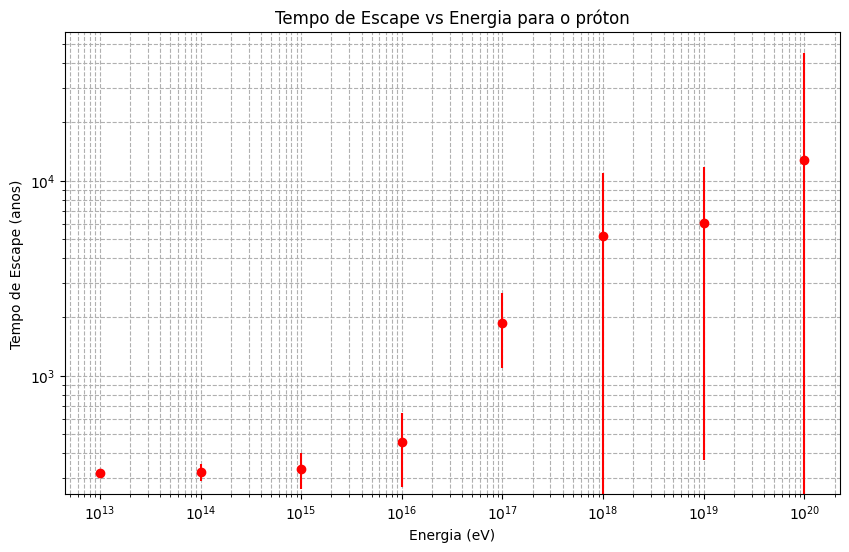

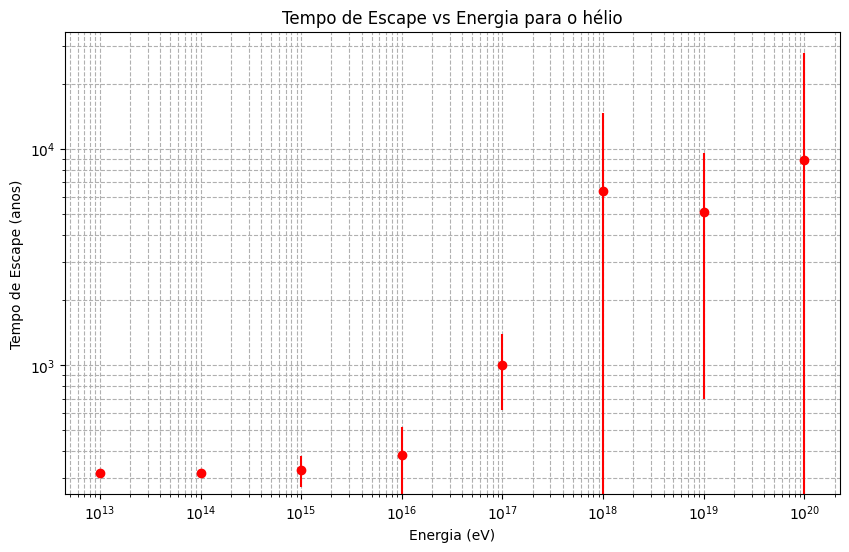

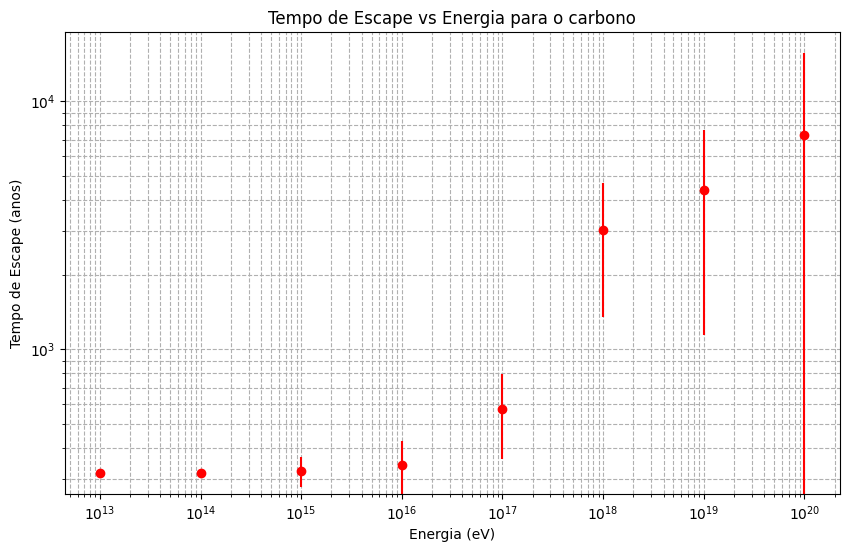

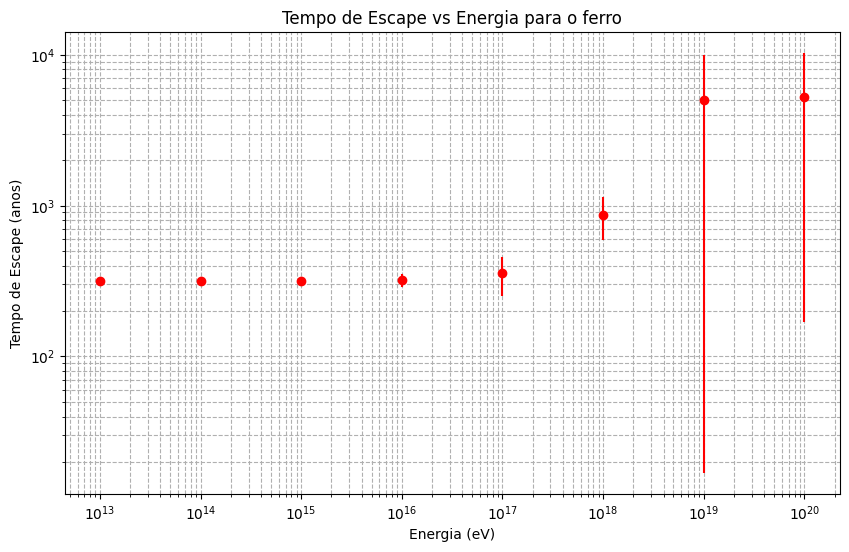

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
e = 1.6e-19 # C
mp = 1.67e-27 # kg
u = 1.66e-27 # kg

import random
def random_direction():
    phi = random.uniform(0, 2 * np.pi)  # azimuthal angle
    costheta = random.uniform(-1, 1)       # cos(theta) uniformly distributed
    theta = np.arccos(costheta)            # polar angle
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    return np.array([x, y, z])


masses = [mp, 4*u, 12*u, 56*u] # kg (próton, hélio, carbono, ferro)
charges = [1.0*e, 2.0*e, 6.0*e, 26.0*e] # cargas (próton, hélio, carbono, ferro)

particle_names = ["próton", "hélio", "carbono", "ferro"]
#masses = [mp, 4*u] # kg teste com próton
#charges = [1.0*e, 2.0*e] # cargas elementares 

for m in masses:
    q = charges[masses.index(m)]
    name = particle_names[masses.index(m)]
    Energies = [1e13, 1e14, 1e15, 1e16, 1e17, 1e18, 1e19, 1e20]  # eV
    B0=[0.0,4E-10,0.0] # Tesla
    r0 = np.array([8.5, 0.0, 0.0]) # kpc
    s=100000

    escape_times = []
 
    for i in range(len(Energies)):
        E = Energies[i]
        energy_times = []
        for j in range(100):  # 1000 simulações para cada energia
            B0=[0.0,4E-10,0.0] # Tesla
            direc_v0 = random_direction()
            v0 = Energy_to_velocity(E, m, direc_v0)
            df, time_years = main_galactic(q, m, r0, v0, E, B0, s=1000000)
            if time_years is not None:
                energy_times.append(time_years)

        if energy_times:
            t_mean=np.mean(energy_times)
            n=len(energy_times)
            inc_t = np.std(energy_times)  

            escape_times.append((E, t_mean, inc_t))

    df=pd.DataFrame(escape_times, columns=['Energy', 't_escape', 'inc_t'])



    Energy = df['Energy']
    t_escape = df['t_escape']
    inc_t = df['inc_t']
    
    plt.figure(figsize=(10, 6))
    plt.errorbar(Energy, t_escape, yerr=inc_t, fmt='o', color='red', label="tempos de escape médios")
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Energia (eV)')
    plt.ylabel('Tempo de Escape (anos)')
    plt.title(f'Tempo de Escape vs Energia para o {name}')
    plt.grid(True, which="both", ls="--")
    plt.show()


    



